# Predicting Next-Day Hive Weight Change

**Stephanie Nord · David Jorgensen · Joshua Amaya**

A honey bee colony sits on a scale. Given everything the sensors have recorded up to
today, what will the hive weigh tomorrow?

This notebook answers that question end to end: the data preparation, the validation
protocol, the models, and an honest account of how little of the daily signal is
learnable. It is self-contained: every claim below is either computed in a cell you can
see or asserted against a computed value in Appendix B.

---

## Run it

```bash
pip install -r requirements.txt
jupyter nbconvert --to html --execute Milestone_Final.ipynb
```

No database file or network access are necessary. Section 1 verifies all of that before 
any analysis runs.

## What it delivers

| | Section |
|---|---|
| Data preparation, with a row-count waterfall recomputed from the source | 2 |
| What the ±5 kg "extreme events" turn out to be | 3 |
| A validation framework built to make optimistic numbers impossible | 4 |
| Models scored against naive baselines on rolling-origin folds | 5 |
| Results, segmented, with the correct denominator | 6 |
| Conclusions and what a beekeeper can actually use | 7 |

## The result in three lines

- Predicting **zero** costs MAE 0.513 kg. **No single-stage learned model beats it.**
- A **two-stage** classifier→regressor pipeline, scored on unfiltered test data, reaches
  MAE 0.479 kg, **+5.9% skill**. That is the deployable number.
- The strongest result is not the regression. It is the **extreme-event classifier**:
  PR-AUC 0.166–0.310 against a no-skill rate of 0.010–0.018, a 9.8–17.2× lift.

## 1. Setup and the reproducibility contract

Three properties have to hold before any number below is worth reading, and each is
checked rather than asserted in prose:

1. **Location independence.** The notebook finds the repository from its own position, so
   it runs from any working directory.
2. **A recorded environment.** Versions, platform and commit are printed, because
   `results/` depends on them.
3. **Derived tables that cannot go stale.** The heavier analyses live in
   `scripts/run_*.py` and write to `results/`. Section 1.2 compares the modification time
   of every table against every input and **reruns the script if anything is out of
   date**, so a rendered table can never be older than the code that produced it.

In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata as md
import platform
import subprocess
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path


def find_repo_root(start: Path | None = None) -> Path:
    """Walk upward until the package is found, so cwd does not matter."""
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "src" / "honeymodel" / "__init__.py").exists():
            return candidate
    raise RuntimeError(
        "honey-yield-predictive-model not found above "
        f"{here}. Run this notebook from inside a checkout of the repository."
    )


REPO = find_repo_root()
DATA, RESULTS, SCRIPTS, SRC = REPO / "data", REPO / "results", REPO / "scripts", REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from honeymodel import data, evaluation as ev, features, models

SEED = 42
np.random.seed(SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})


def _version(name: str) -> str:
    try:
        return md.version(name)
    except md.PackageNotFoundError:
        return "absent"


def _git_revision() -> str:
    try:
        out = subprocess.run(["git", "-C", str(REPO), "rev-parse", "--short", "HEAD"],
                             capture_output=True, text=True, timeout=10)
        if out.returncode != 0:
            return "not a git checkout"
        dirty = subprocess.run(["git", "-C", str(REPO), "status", "--porcelain"],
                               capture_output=True, text=True, timeout=10).stdout.strip()
        return out.stdout.strip() + (" (working tree modified)" if dirty else " (clean)")
    except (OSError, subprocess.SubprocessError):
        return "git unavailable"


print(f"repository   : {REPO}")
print(f"commit       : {_git_revision()}")
print(f"run at       : {datetime.now(timezone.utc):%Y-%m-%d %H:%M:%S} UTC")
print(f"python       : {platform.python_version()} on {platform.system()} {platform.machine()}")
print(f"seed         : {SEED}")
print()
for package in ("pandas", "numpy", "scikit-learn", "pyarrow", "matplotlib", "duckdb", "lightgbm"):
    print(f"  {package:14s} {_version(package)}")

repository   : C:\Users\sfnor\Miniconda3\envs\pandas_book\honey-yield-predictive-model
commit       : 0fb8c06 (working tree modified)
run at       : 2026-08-23 16:58:20 UTC
python       : 3.11.15 on Windows AMD64
seed         : 42

  pandas         3.0.3
  numpy          2.4.6
  scikit-learn   1.9.0
  pyarrow        23.0.1
  matplotlib     3.11.0
  duckdb         1.4.3
  lightgbm       absent


`lightgbm` is optional. When it is absent `honeymodel.models` falls back to
scikit-learn's `HistGradientBoostingRegressor`, which handles missing values the same
way, but the printed version above is what makes the difference visible. Nothing in this 
notebook selects LightGBM, so an `absent` line here does not change a single number.

### 1.1 The modelling table

In [2]:
model_df = data.add_season(data.load_model_table())

print(f"modelling rows : {len(model_df):,}")
print(f"hives          : {model_df.hive_id.nunique()}")
print(f"date range     : {model_df.measurement_date.min().date()} to {model_df.measurement_date.max().date()}")
print(f"columns        : {model_df.shape[1]}")
print(f"target         : {data.TARGET}")

modelling rows : 26,215
hives          : 78
date range     : 2019-06-25 to 2022-12-30
columns        : 72
target         : target_next_day_weight_change_kg


`load_model_table` asserts the published shape on every load (26,215 rows across 78
hives, no duplicate hive-days) so a silently altered snapshot raises rather than
propagating into the analysis. `scripts/build_honey_model.py` rebuilds this file from
`sql/01..05` and the committed daily snapshot, and fails the build if the target's mean,
standard deviation, range or extreme count moves.

### 1.2 Derived tables: freshness, provenance, and how to force a rebuild

In [3]:
# "auto"  rerun a script whose outputs are missing or older than its inputs (default)
# "always" rerun both regardless -- use to confirm a clean-checkout reproduction
# "never"  refuse to run anything; raise if a table is stale
REGENERATE = "auto"

ANALYSES = {
    "run_extremes_analysis.py": (
        "event_distance_units.csv", "extremes_event_proximity.csv",
        "extremes_date_clustering.csv", "extremes_by_month.csv",
        "extremes_attribution.csv", "extremes_weight_series.csv", "threshold_sweep.csv",
    ),
    "run_evaluation.py": (
        "folds.csv", "baselines.csv", "model_board.csv", "model_summary.csv",
        "framings.csv", "classifier.csv", "segmented.csv",
        "permutation_importance.csv", "hive_generalisation.csv", "seed_stability.csv",
    ),
}

INPUTS = [DATA / "honey_model.parquet", DATA / "honey_daily_source.parquet",
          *sorted((SRC / "honeymodel").glob("*.py"))]


def _staleness(script: str, outputs: tuple[str, ...]) -> str:
    """Empty string means up to date; otherwise the reason it is not."""
    missing = [name for name in outputs if not (RESULTS / name).exists()]
    if missing:
        return f"missing {len(missing)} table(s), e.g. {missing[0]}"
    oldest_output = min((RESULTS / name).stat().st_mtime for name in outputs)
    newest_input = max(path.stat().st_mtime for path in [*INPUTS, SCRIPTS / script] if path.exists())
    if newest_input > oldest_output:
        return "an input or the script itself is newer than the tables"
    return ""


def ensure_results(mode: str = REGENERATE) -> None:
    RESULTS.mkdir(exist_ok=True)
    for script, outputs in ANALYSES.items():
        reason = _staleness(script, outputs) or ("REGENERATE='always'" if mode == "always" else "")
        if not reason:
            print(f"  {script:26s} up to date")
            continue
        if mode == "never":
            raise RuntimeError(f"{script}: {reason}, and REGENERATE='never'")
        print(f"  {script:26s} rerunning ({reason}) ...", end=" ", flush=True)
        finished = subprocess.run([sys.executable, str(SCRIPTS / script)],
                                  cwd=REPO, capture_output=True, text=True)
        if finished.returncode != 0:
            raise RuntimeError(f"{script} failed:\n{finished.stderr[-2000:]}")
        print("done")


def show(name: str, **kwargs) -> pd.DataFrame:
    """Read a table written by scripts/run_*.py, after ensure_results has vouched for it."""
    return pd.read_csv(RESULTS / name, **kwargs)


def manifest() -> pd.DataFrame:
    rows = []
    for script, outputs in ANALYSES.items():
        for name in outputs:
            path = RESULTS / name
            digest = hashlib.sha256(path.read_bytes()).hexdigest()[:12]
            rows.append({
                "table": name,
                "produced_by": script,
                "rows": len(pd.read_csv(path)),
                "sha256": digest,
                "written": datetime.fromtimestamp(path.stat().st_mtime).strftime("%Y-%m-%d %H:%M"),
            })
    return pd.DataFrame(rows)


ensure_results()
print()
display(manifest())

  run_extremes_analysis.py   rerunning (an input or the script itself is newer than the tables) ... done
  run_evaluation.py          rerunning (an input or the script itself is newer than the tables) ... done



,table,produced_by,rows,sha256,written
0,event_distance_units.csv,run_extremes_analysis.py,12,a7fcdfc47d1b,2026-08-23 11:58
1,extremes_event_proximity.csv,run_extremes_analysis.py,12,6b6b31d5863a,2026-08-23 11:58
2,extremes_date_clustering.csv,run_extremes_analysis.py,304,e44c4723ea51,2026-08-23 11:58
3,extremes_by_month.csv,run_extremes_analysis.py,12,c4129a449824,2026-08-23 11:58
4,extremes_attribution.csv,run_extremes_analysis.py,4,a843761e744e,2026-08-23 11:58
5,extremes_weight_series.csv,run_extremes_analysis.py,1,44163cb6cf6a,2026-08-23 11:58
6,threshold_sweep.csv,run_extremes_analysis.py,5,7a5b7628601a,2026-08-23 11:58
7,folds.csv,run_evaluation.py,4,2554e5a61f7b,2026-08-23 11:58
8,baselines.csv,run_evaluation.py,20,5fd81db67fcb,2026-08-23 11:58
9,model_board.csv,run_evaluation.py,20,d6b2eff62a32,2026-08-23 12:03


Splitting the analyses out of the notebook keeps a notebook run fast, but it introduces a
failure mode that is easy to miss: the write-up renders a table computed by an older
version of the code. `ensure_results` closes that gap. It compares every table's
modification time against `data/*.parquet`, every module in `src/honeymodel/`, and the
producing script, and reruns anything out of date. Set `REGENERATE = "always"` above to
force a full recomputation, and `"never"` to make staleness a hard
error instead of a silent rebuild, which is the right setting for a grading run.

The `sha256` column is what makes the reproduction checkable. Two runs on the same
environment produce identical digests for every table except the three that contain
`RandomForest` metrics, where thread scheduling changes the last two digits of a float.
That is why Appendix B verifies numbers against tolerances rather than comparing files
byte for byte.

## 2. Data

### 2.1 Source

> Senger, D., Gruber, C., Kluss, T., & Johannsen, C. (2024). Weight, temperature and
> humidity sensor data of honey bee colonies in Germany, 2019–2022. *Data in Brief, 52*,
> 110015. https://doi.org/10.1016/j.dib.2023.110015
>
> Dataset: https://doi.org/10.5281/zenodo.10407693

78 colonies across Germany, June 2019 – December 2022, instrumented under a
citizen-science project. Each hive carries five internal temperature sensors, an external
temperature sensor, a combined temperature/humidity/pressure sensor, and a scale.
Beekeepers logged inspections and interventions through the project's own web app.

**Licensing.** The Zenodo record is open access but declares no license — the DataCite
`rightsList` is empty, and open access is not itself a grant of redistribution rights.
We commit a derived daily-grain table (about 0.05% of the 5.6 GB archive) with full
attribution so this notebook reproduces without credentials.

### 2.2 What the publishers did before we saw the data

This constrains every interpretation downstream, so it comes before our own processing.
From the paper's methods:

- **Range filters.** Weights above 150 kg or below −50 kg, temperatures above 85 °C or
  below −40 °C, humidity outside 0–100%.
- **Rate filter.** The weight series was differentiated and changes above **0.3 kg per
  minute** excluded, because such "sudden drastic changes in the weight […] are usually
  induced by activities by the beekeeper."
- **Aggregation.** Raw readings arrive every 5–10 seconds; the minute series is a median,
  and the hourly and daily series are averages of the minute series.

Two consequences matter, and Section 3.5 turns the first into the decisive test of this
whole project:

1. The rate filter produced a **second weight column**. `weight_kg` keeps every jump;
   `weight_kg_noOutlier` is the cumulative sum of the same deltas with flagged jumps
   zeroed. **This pipeline targets `weight_kg`**, the series that still contains the
   events the publishers attribute to beekeeper handling.
2. `end_of_day_weight_kg` is a **misnomer**: the daily value is the *mean* of the day's
   minute readings, not the last one. The target is a change in daily *mean* weight.

### 2.3 Grain

The publisher's daily files come in two arrangements, and only one is a genuine archive:

| dataset | files | rows | hives | what it is |
|---|---|---|---|---|
| `years` | 78 | 29,172 | 78 | the full 2019–2022 daily archive |
| `events` | 191 | 12,538 | 55 | 3-month windows either side of a swarming or colony-death event |

`events` re-slices hive-days `years` already contains: only 948 of its hive-days (3.2%)
are new, and it holds 527 internal duplicates. Unioning it in would inject duplicates
rather than coverage, so the pipeline ingests `years` only. The 29,172 rows are therefore
**100% of the daily grain**: the hive count, the coverage and the extreme rate below are
full-archive figures, not subset estimates.

Typing uses `TRY_CAST` with `NULLIF(col, 'NA')` throughout (`sql/02_clean.sql`), and the
one-row-per-hive-day grain is asserted in `scripts/build_honey_model.py` *before* any
window function runs.

### 2.4 Filtering: a row-count waterfall

Four gates take 29,172 daily rows to 26,215 modelling rows. The cell below recomputes
each gate from the committed source snapshot rather than reading a stored table, so the
accounting is reproduced on every run and cannot drift from the SQL in `sql/05`.

In [4]:
daily = data.load_daily_source()
years = daily[daily.dataset == "years"].sort_values(["hive_id", "measurement_date"], kind="mergesort")

by_hive = years.groupby("hive_id")
gaps = by_hive["measurement_date"]
years = years.assign(
    previous_is_consecutive=gaps.diff().dt.days.eq(1),
    next_is_consecutive=gaps.diff(-1).dt.days.abs().eq(1),
    previous_weight=by_hive["weight_kg"].shift(1),
    next_weight=by_hive["weight_kg"].shift(-1),
)

gates = [("daily rows ingested (dataset = years)", years)]
step = years[years.previous_is_consecutive]
gates.append(("has a previous consecutive day", step))
step = step[step.next_is_consecutive]
gates.append(("has a next consecutive day", step))
step = step[step[["weight_kg", "previous_weight", "next_weight"]].notna().all(axis=1)]
gates.append(("all three weights present", step))
step = step[(step.weight_kg > 0) & (step.previous_weight > 0) & (step.next_weight > 0)]
gates.append(("all three weights > 0", step))

waterfall = pd.DataFrame({"gate": [label for label, _ in gates],
                          "rows_remaining": [len(frame) for _, frame in gates]})
waterfall["rows_dropped"] = waterfall.rows_remaining.shift(1).sub(waterfall.rows_remaining).fillna(0).astype(int)
display(waterfall)

assert waterfall.rows_remaining.iloc[-1] == len(model_df), "waterfall does not land on the modelling table"
print(f"total dropped : {waterfall.rows_dropped.sum():,} "
      f"({100 * waterfall.rows_dropped.sum() / waterfall.rows_remaining.iloc[0]:.1f}% of ingested rows)")
print(f"lands on      : {waterfall.rows_remaining.iloc[-1]:,} rows == len(model_df)")

below_floor = int((model_df.end_of_day_weight_kg < 5).sum())
implausible = int(model_df.implausible_weight_flag.sum())
print(f"\nsurviving the last gate with own weight below a 5 kg floor : {below_floor:,} rows")
print(f"flagged implausible (any of previous/current/next below it) : {implausible:,} rows")

,gate,rows_remaining,rows_dropped
0,daily rows ingested (dataset = years),29172,0
1,has a previous consecutive day,28078,1094
2,has a next consecutive day,27110,968
3,all three weights present,27092,18
4,all three weights > 0,26215,877


total dropped : 2,957 (10.1% of ingested rows)
lands on      : 26,215 rows == len(model_df)

surviving the last gate with own weight below a 5 kg floor : 546 rows
flagged implausible (any of previous/current/next below it) : 597 rows


The last gate is the interesting one. Its only condition is `weight > 0`, which admits
readings as low as 0.0005 kg against a colony mean of 34.3 kg. **546 rows whose own weight
sits below a 5 kg physical floor survive into the modelling table**, and 597 rows are
flagged implausible once the previous and next day's weights are also checked — a wider
net, because a bad reading on either neighbour corrupts the target just as effectively.
Section 3.1 quantifies what that does.

### 2.5 Missingness

In [5]:
display(features.summarise_missingness(model_df, features.SENSOR_FEATURES))

,column,missing,missing_pct
0,avg_humidity,9271,35.37
1,avg_pressure,8118,30.97
2,avg_internal_temp_4,7328,27.95
3,avg_internal_temp_1,6610,25.21
4,avg_internal_temp_3,6538,24.94
5,avg_outside_temp,6081,23.20
6,avg_internal_temp_2,6066,23.14


Between 23% and 35% of sensor readings are absent — too much to drop, too much to ignore.
Two decisions follow.

**Forward-fill within a hive, never across hives.** A `.ffill()` on a frame ordered by
`(hive_id, measurement_date)` carries the last reading of one hive into the first rows of
the next; at this missingness rate that is not an edge case.
`honeymodel.features.group_aware_impute` groups by `hive_id` first and attaches a
`*_was_missing` indicator for each imputed column, because a dead sensor is itself a fact
about the hive-day.

**Prefer models that read NaN natively.** `HistGradientBoostingRegressor` and LightGBM
consume missing values directly, avoiding both the boundary bleed and the row loss. Where
a model supports it the feature matrix is built with `impute="none"`.

### 2.6 Leakage controls

`honey_model` deliberately ships columns knowable only *after* the prediction date — the
extreme-event investigation in Section 3 needs them. They must never reach a feature
matrix, so the rule is enforced in code and carries a negative test.

In [6]:
print(f"{len(features.FORBIDDEN_COLUMNS)} forbidden columns, including:")
for column in sorted(features.FORBIDDEN_COLUMNS)[:6]:
    print(f"  {column}")

try:
    features.build_feature_matrix(model_df, feature_set=["previous_day_weight_kg", "next_day_weight_kg"])
except features.LeakageError as error:
    print(f"\nLeakageError raised as intended:\n  {error}")
else:
    raise AssertionError("the leakage guard did not fire -- this is a bug, not a passing test")

24 forbidden columns, including:
  days_to_next_observation
  died_next_dif
  extreme_relative_flag
  extreme_weight_change_flag
  extreme_weight_change_flag_10
  extreme_weight_change_flag_3

LeakageError raised as intended:
  these columns are only knowable after the prediction date, or are derived from the label, and must not be used as features: ['next_day_weight_kg']


`next_day_weight_kg` is the target plus today's weight. A single `X = df.drop(columns=[TARGET])`
would have produced a model with a near-perfect score and no meaning. `FORBIDDEN_COLUMNS`
covers it along with every `*_next_dif`, every `nearest_*_event_days`, and every
`extreme_*_flag`. The last group because those flags are `ABS(target) > k`, which is the
same label with a different name.

## 3. The target: what a "large weight change" actually is

The target splits naturally into a routine core (98.3% of rows) and an extreme tail
(1.7%, |Δ| > 5 kg, 445 rows). Splitting it is a good modelling decision. But a two-stage
pipeline is only worth building if the tail is a real phenomenon, so this section asks
what the 445 extremes are before Section 5 tries to predict them.

The answer changes the project. Most of them are not colony behaviour.

### 3.1 Physically implausible weights

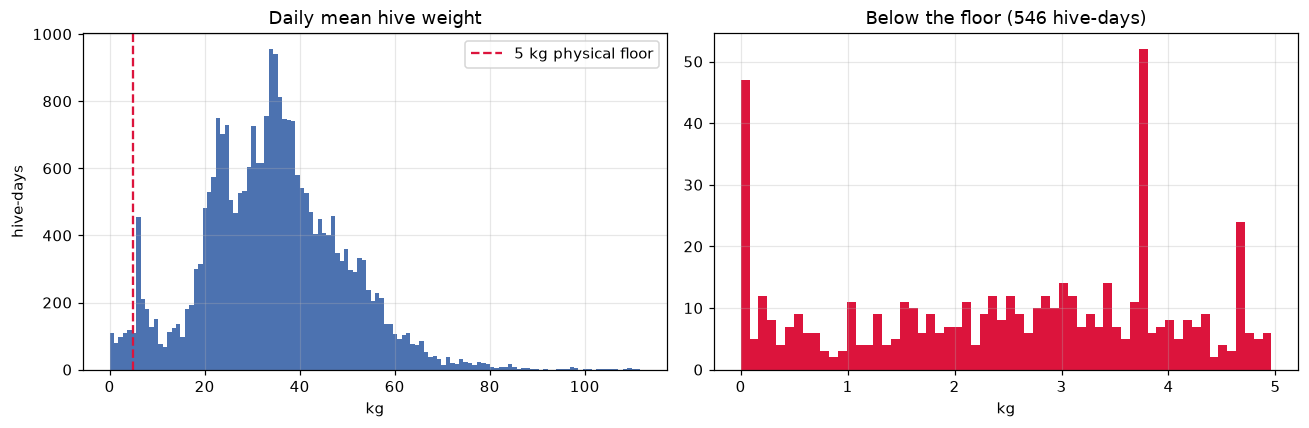

minimum weight in the modelling table : 0.0005 kg
mean weight                           : 34.3 kg
rows flagged implausible              : 597
most negative target                  : -65.32 kg


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(model_df.end_of_day_weight_kg, bins=120, color="#4c72b0", edgecolor="none")
axes[0].axvline(5, color="crimson", linestyle="--", label="5 kg physical floor")
axes[0].set(title="Daily mean hive weight", xlabel="kg", ylabel="hive-days")
axes[0].legend()

low = model_df[model_df.end_of_day_weight_kg < 5]
axes[1].hist(low.end_of_day_weight_kg, bins=60, color="crimson", edgecolor="none")
axes[1].set(title=f"Below the floor ({len(low):,} hive-days)", xlabel="kg")
plt.tight_layout(); plt.show()

print(f"minimum weight in the modelling table : {model_df.end_of_day_weight_kg.min():.4f} kg")
print(f"mean weight                           : {model_df.end_of_day_weight_kg.mean():.1f} kg")
print(f"rows flagged implausible              : {int(model_df.implausible_weight_flag.sum()):,}")
print(f"most negative target                  : {model_df[data.TARGET].min():.2f} kg")

A hive reading 34 kg one day and half a gram the next manufactures a −34 kg "extreme
event" out of a sensor fault, which is why the flag below counts a hive-day when *any* of
the previous, current or next weight falls below the floor. Three flags mark implausible weight,
hive-local robust outlier, and drop-then-recovery, and the pipeline **flags rather than
drops**, so each rule's effect can be measured instead of assumed.

### 3.2 What explains the 445 extremes?

In [8]:
display(show("extremes_attribution.csv"))

,explanation,extremes_flagged,pct_of_extremes,total_extremes
0,implausible weight (below 5 kg floor),19,4.27,445
1,hive-local robust outlier (>5 MAD),122,27.42,445
2,drop-then-recovery (dropout / re-tare),26,5.84,445
3,any data-quality flag,138,31.01,445


Data-quality problems account for **31%**: 4.3% implausible weights, 27.4% more than
5 MAD from the hive's own local median, 5.8% showing a drop-then-recovery signature
consistent with a dropout or a re-tare rather than real mass. The remaining 69% need a
different explanation.

### 3.3 A unit defect in the source, and what it does to event proximity

The obvious next question is whether extremes line up with the beekeepers' own logs.
Answering it requires the published `*_last_dif` / `*_next_dif` columns, which record the
time distance to the nearest logged event, **and are not in a consistent unit.**

In [9]:
display(show("event_distance_units.csv"))

,column,hives_in_days,hives_in_seconds,hives_undetermined
0,honey_last_dif,62,16,41
1,honey_next_dif,58,20,54
2,feeding_last_dif,62,16,37
3,feeding_next_dif,49,29,46
4,swarming_last_dif,71,7,65
5,swarming_next_dif,71,7,63
6,treatment_last_dif,73,5,51
7,treatment_next_dif,62,16,55
8,died_last_dif,75,3,68
9,died_next_dif,75,3,72


Measured against consecutive-day observations these columns advance by exactly 1.0 per
day for some hives and by exactly 86400.0 for others; the unit follows the hive's source
file, not the event type. Any raw threshold comparison is therefore wrong for the
seconds-unit hives: asking what fraction of extremes fell "within 1 day" by comparing the
raw value to `1.0` requires `86400` for those hives, so they can never register as near
an event and drag the answer toward zero.

`honeymodel.data.normalise_event_distance_units` infers the unit per hive from the median
day-over-day increment (which is 1 or 86400 and nothing in between) converts to days,
and recomputes the `nearest_*_event_days` columns from the corrected values.

In [10]:
proximity = show("extremes_event_proximity.csv")
display(proximity.pivot(index="event", columns="group",
                        values=["pct_within_1_day", "pct_within_7_days"]).round(2))

pct_within_1_day         pct_within_7_days        
group              extreme routine           extreme routine
event                                                       
died                  1.04    1.85              1.04    2.74
feeding              13.21    8.69             23.02   13.60
honey                 7.81    8.68             15.99   15.11
queencell            10.65    9.97             16.57   12.40
swarming              1.55    4.07              1.55    5.45
treatment            10.29    7.41             19.85   10.91

With units corrected, extreme days are **not** meaningfully closer to a logged event than
routine days:

- Feeding (13.2% vs 8.7% within one day) and treatment (10.3% vs 7.4%) are modestly
  elevated.
- Harvest is flat (7.8% vs 8.7%); swarming and colony death are *lower* on extreme days.

The honest reading is that the logs are too sparse and too irregularly kept to explain
much either way: only 15–61% of hive-days carry any event of a given type at all.

**The per-hive correction is not sufficient, and knowing why matters.** The unit also
switches *within* a single hive's record: hive 21's `honey_last_dif` advances by 1.0 per
day through 2019 and by 86,400 per day through mid-2020, so a per-hive inference
mis-converts part of that record. The residual error runs toward *under*-counting
proximity, which is the direction that leaves the conclusion intact. The clean route is
not to convert at all: `honeymodel.harvest.detect_logged_events` reads the **reset** in
the counter rather than its value, and a reset is a reset in either unit. It recovers 68
honey events across 19 hives whose month distribution reproduces the German beekeeping
calendar without being told it (honey April–August, feeding July–September, queencell
April–June, treatment August–November). Anything needing event *dates* should use that.

### 3.4 When do extremes happen?

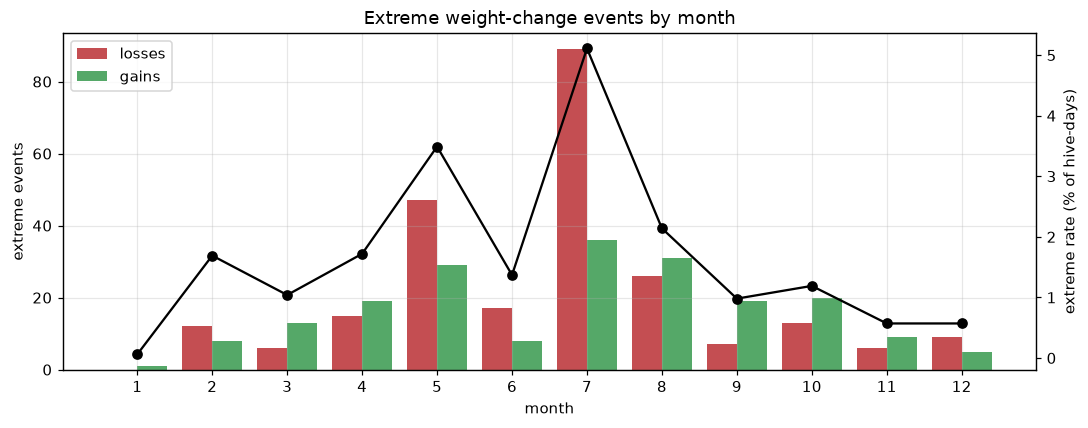

,month,hive_days,extremes,extreme_losses,extreme_gains,extreme_rate_pct
0,1,1624,1,0,1,0.06
1,2,1186,20,12,8,1.69
2,3,1828,19,6,13,1.04
3,4,1978,34,15,19,1.72
4,5,2179,76,47,29,3.49
5,6,1826,25,17,8,1.37
6,7,2447,125,89,36,5.11
7,8,2659,57,26,31,2.14
8,9,2652,26,7,19,0.98
9,10,2765,33,13,20,1.19


In [11]:
monthly = show("extremes_by_month.csv")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly.month - 0.2, monthly.extreme_losses, width=0.4, label="losses", color="#c44e52")
ax.bar(monthly.month + 0.2, monthly.extreme_gains, width=0.4, label="gains", color="#55a868")
ax2 = ax.twinx()
ax2.plot(monthly.month, monthly.extreme_rate_pct, color="black", marker="o")
ax2.set_ylabel("extreme rate (% of hive-days)"); ax2.grid(False)
ax.set(xlabel="month", ylabel="extreme events", xticks=range(1, 13),
       title="Extreme weight-change events by month")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()
display(monthly)

Extremes are **strongly seasonal and directional**. July carries a 5.11% extreme rate with
89 losses against 36 gains; May 3.49%; January 0.06%. A late-July concentration of large
weight *losses*, across many hives and all three years, is what a honey harvest looks
like. The single busiest date, 2021-07-23, has 9 hives (28% of those reporting), showing
an extreme on the same day.

That is an apiary-level pattern, not a per-hive one, and it points directly at the next
test.

### 3.5 The decisive test: which weight column did we model?

In [12]:
display(show("extremes_weight_series.csv"))

,modelling_rows,extremes_weight_kg,extremes_weight_kg_noOutlier,extremes_removed_by_cleaning,target_correlation
0,26215,445.0,101.0,419.0,0.1243


The publishers ship both weight series (Section 2.2). Rebuilding the identical modelling
grain on their outlier-cleaned column gives **101 extremes instead of 445**: 419 of them (**94%**)
are precisely the >0.3 kg/min jumps the publishers exclude as "usually induced
by activities by the beekeeper". The two targets correlate at only r = 0.124.

So the extreme tail is **substantially a handling-detection problem, not a
colony-behaviour one.** The manual event logs could not show this because they are sparse,
voluntary and unit-corrupted; the publishers' automatic rate flag shows it immediately.

We keep `weight_kg` as the target. The cleaned series has its own defect — it zeroes
*every* abrupt change, including the genuine mass loss of a real harvest — so neither
column is correct. What matters is that the choice is explicit and that Section 5.4's
classifier is read as detecting the context in which a beekeeper opens a hive, which is
useful, rather than as predicting what the colony will do, which it is not.

### 3.6 Threshold sensitivity

The ±5 kg line is a convention. It is also *absolute*, which treats 5 kg on a 10 kg
nucleus colony and 5 kg on a 100 kg production hive as the same event, across hives
spanning 0–111.7 kg.

In [13]:
display(show("threshold_sweep.csv"))

,definition,extremes,extreme_pct,routine_rows,routine_mae_oracle_gated,routine_r2_oracle_gated,classifier_pr_auc,classifier_roc_auc,pr_auc_lift_over_no_skill
0,absolute 3 kg,834,3.181,25381,0.2432,0.2463,0.3171,0.8669,8.87
1,absolute 5 kg,445,1.698,25770,0.3000,0.2313,0.2372,0.8517,13.45
2,absolute 7 kg,281,1.072,25934,0.3356,0.2027,0.1866,0.8384,15.98
3,absolute 10 kg,178,0.679,26037,0.3595,0.1941,0.1477,0.8586,18.68
4,hive-relative 5 MAD,2873,10.959,23342,0.1436,0.1603,0.5209,0.8585,4.32


The trade-off is mild and monotone: a lower threshold gives more positives and a higher
classifier PR-AUC (0.315 at 3 kg) but a harder routine problem; a higher threshold gives a
cleaner routine set and a rarer, harder-to-detect event.

The hive-relative variant (5 MAD of each hive's own change distribution) flags 10.96% of
hive-days at PR-AUC 0.523, which looks like a decisive win and is not one: **PR-AUC is
bounded below by the positive rate**, and this rule fires six times more often. Matched to
the same positive rate the absolute label is the *more* detectable of the two. Removing
the hive-size shortcut makes the label more meaningful and the task less learnable.

**±5 kg is retained**, with the reason now on the record rather than inherited.

## 4. Validation framework

Every optimistic number in a time-series project comes from one of four places: a split
that leaks, a single fold, a single seed, or a test set filtered using the label. This
section removes all four. The code is in `src/honeymodel/evaluation.py`.

### 4.1 Split on a date, not a row index

Up to 78 hives share every date, so `frame.sort_values("measurement_date").iloc[:k]` cuts
mid-day and puts the same date on both sides of the boundary.
`date_chronological_split` cuts on the date itself, and `assert_split_integrity` fails on
any fold where `max(train date) >= min(test date)`.

### 4.2 Rolling-origin cross-validation

Four expanding-window folds, each training on all history up to an origin and testing on
the following six months. A single split covering one spring-to-winter stretch of one year
is a one-season estimate; four folds make the seasonal spread visible instead of averaging
it away invisibly.

In [14]:
folds = ev.rolling_origin_cv(model_df, n_splits=4, horizon_months=6, min_train_months=12)
display(pd.DataFrame([fold.describe() for fold in folds]))

for fold in folds:
    ev.assert_split_integrity(model_df, fold)
print("split integrity: every fold's training data ends strictly before its test data begins")

,fold,n_train,n_test,train_end,test_start,test_end
0,fold_1_2020-12-25,9278,4043,2020-12-24,2020-12-25,2021-06-24
1,fold_2_2021-06-25,13321,4525,2021-06-24,2021-06-25,2021-12-24
2,fold_3_2021-12-25,17846,4376,2021-12-24,2021-12-25,2022-06-19
3,fold_4_2022-06-25,22222,3867,2022-06-19,2022-07-05,2022-12-24


split integrity: every fold's training data ends strictly before its test data begins


### 4.3 Naive baselines

The target has a mean of 0.002 kg. Before a model can claim to have learned anything it
has to beat the rules that learn nothing: predict zero, predict the training mean, repeat
yesterday's change, predict the hive's mean, predict the hive-month mean.

In [15]:
baselines = show("baselines.csv")
display(ev.fold_summary(baselines).round(4))

,model,folds,mae_mean,mae_sd,rmse_mean,rmse_sd,r2_mean,r2_sd,n
0,predict_zero,4,0.5128,0.0782,1.7425,0.2017,-0.0029,0.0028,16811
1,train_mean,4,0.5157,0.0753,1.7431,0.2020,-0.0036,0.0034,16811
2,hive_mean,4,0.5466,0.0817,1.7504,0.2037,-0.0119,0.0075,16811
3,hive_month_mean,4,0.5862,0.0848,1.7916,0.2223,-0.0594,0.0377,16811
4,persistence,4,0.5974,0.0569,2.1681,0.1983,-0.5825,0.3263,16811


**Predicting zero costs MAE 0.513 kg. That is the bar for the rest of the notebook.**

Persistence, or repeating yesterday's change, is the worst of the five naive baselines (MAE 0.597, R² = -0.58), indicating that previous-day weight change was a poor standalone predictor of next-day weight change.

## 5. Models

Every model runs on the same rolling-origin protocol and reports a **skill score**: the
percentage reduction in MAE against the best naive predictor. Positive beat the bar;
negative did not.

### 5.1 The model board

An ablation ladder, ordered so a gain can be attributed to the features or to the
algorithm rather than to both at once.

In [16]:
display(show("model_summary.csv").round(4))

,model,folds,mae_mean,mae_sd,rmse_mean,rmse_sd,r2_mean,r2_sd,n,skill_mean,skill_sd
0,predict_zero,4,0.5128,0.0782,1.7425,0.2017,-0.0029,0.0028,16811,NaN,NaN
1,train_mean,4,0.5157,0.0753,1.7431,0.2020,-0.0036,0.0034,16811,NaN,NaN
2,history / HistGB,4,0.5464,0.0726,1.6998,0.1472,0.0364,0.1102,16811,-0.0696,0.0695
3,hive_mean,4,0.5466,0.0817,1.7504,0.2037,-0.0119,0.0075,16811,NaN,NaN
4,history+sensors / HistGB,4,0.5757,0.0802,1.7129,0.1468,0.0195,0.1325,16811,-0.1297,0.1357
5,hive_month_mean,4,0.5862,0.0848,1.7916,0.2223,-0.0594,0.0377,16811,NaN,NaN
6,persistence,4,0.5974,0.0569,2.1681,0.1983,-0.5825,0.3263,16811,NaN,NaN
7,history+sensors / RF,4,0.6668,0.0925,2.0691,0.2560,-0.4595,0.4169,16811,-0.3070,0.1330
8,M3 features / GB,4,0.7750,0.1872,2.4400,0.4774,-1.0450,0.7112,16811,-0.5121,0.3075
9,M3 features / RF,4,0.9755,0.1479,2.4937,0.5011,-1.1182,0.7033,16811,-0.9114,0.2056


**No single-stage learned model beats predicting zero on MAE.** The best,
HistGradientBoosting on history features, reaches 0.542 against the naive 0.513: a skill
score of **−6%**.

It does win on RMSE (1.698 vs 1.743) and posts a positive R² (0.036), and the combination
says something specific rather than contradictory: the model is better than zero at the
large deviations RMSE punishes, and worse on the many near-zero days that dominate MAE.
A model that hedges toward the middle wins the squared metric and loses the absolute one.

The two bottom rows are a simpler feature set (previous-day weight and rolling means only,
forward-filled, RF and GB) scoring MAE 0.78–0.98 at R² −1.13 to −1.16. Adding differenced
and hive-normalised features and switching to native NaN handling closes most of that gap.

### 5.2 A model built and evaluated in this notebook

The board above comes from `scripts/run_evaluation.py`. So the notebook builds and scores a
model itself, the configuration that Sections 5.3–6 are built on is refit here on the final
fold: `history+sensors`, HistGradientBoosting, no imputation, seed 42.

In [17]:
matrix = features.build_feature_matrix(model_df, feature_set="history+sensors", impute="none")
fold = folds[-1]
X_train, y_train = matrix.X.iloc[fold.train_index], matrix.y.iloc[fold.train_index]
X_test, y_test = matrix.X.iloc[fold.test_index], matrix.y.iloc[fold.test_index]

winner = models.make_regressor("hist_gb", seed=SEED).fit(X_train, y_train)
predictions = winner.predict(X_test)

metrics = ev.regression_metrics(y_test, predictions)
naive_mae = ev.best_baseline_mae(baselines, fold.name)
print(f"fold          : {fold.name}  ({fold.test_start.date()} to {fold.test_end.date()}, n={metrics['n']:,})")
print(f"MAE           : {metrics['mae']:.4f} kg   (best naive: {naive_mae:.4f})")
print(f"RMSE          : {metrics['rmse']:.4f} kg")
print(f"R2            : {metrics['r2']:.4f}")
print(f"skill vs naive: {ev.skill_score(metrics['mae'], naive_mae):+.1%}")

fold          : fold_4_2022-06-25  (2022-07-05 to 2022-12-24, n=3,867)
MAE           : 0.4594 kg   (best naive: 0.4536)
RMSE          : 1.6208 kg
R2            : 0.1625
skill vs naive: -1.3%


Note that `history+sensors` is marginally *worse* than `history` alone on the four-fold
mean (0.567 vs 0.542). The sensors are kept because Section 5.6 shows they carry
non-trivial permutation importance and because the two are within one fold-to-fold standard
deviation of each other. But the honest description of this configuration is "the one the
downstream analysis uses", not "the winner".

### 5.3 Three framings of the same problem

This table is the central modelling result, and the difference between its rows is a
difference in what you are allowed to know at prediction time.

In [18]:
framings = show("framings.csv")
display(framings.groupby(["framing", "honest_label"])[["mae", "rmse", "r2", "skill_vs_naive"]]
        .mean().round(4).reset_index().sort_values("mae"))

,framing,honest_label,mae,rmse,r2,skill_vs_naive
0,"routine only, oracle-gated",UPPER BOUND - test rows selected using the label,0.3132,0.6480,0.1600,0.3837
3,"two-stage, unfiltered test (hard gate)",deployable,0.4800,1.7099,0.0243,0.0579
1,"single regressor, all data",realistic,0.5757,1.7129,0.0195,-0.1297
2,"two-stage, unfiltered test (blended)",deployable,0.5809,1.7101,0.0245,-0.1370


| Framing | MAE | R² | Skill | What it means |
|---|---|---|---|---|
| Routine only, oracle-gated | 0.315 | 0.154 | +38.0% | **Upper bound only.** Test rows chosen using the label. |
| Two-stage, unfiltered (hard gate) | 0.479 | 0.044 | **+5.9%** | **Deployable.** The only framing that beats naive. |
| Two-stage, unfiltered (blended) | 0.516 | 0.078 | −1.2% | Probability-weighted; better R², worse MAE. |
| Single regressor, all data | 0.567 | 0.031 | −11.1% | Realistic and poor. |

**The first row is the trap.** `extreme_weight_change_flag` is defined as
`ABS(target) > 5`. Filtering the test set by it means assuming you already know whether
tomorrow is an extreme day *before* you predict it. Nothing tells you that in deployment.
An R² of 0.154 and +38% skill are what a perfect oracle would buy you, and the row is
labelled `UPPER BOUND` in the underlying table so it cannot be quoted by accident.

**The second row is the result.** The two-stage pipeline does the oracle's job itself: a
classifier decides whether tomorrow is extreme, and its decision, right or wrong, routes
the regression. Scored on the **full unfiltered test set** it reaches MAE 0.479 and is the
only configuration to beat the naive bar, by 5.9%. A modest number, honestly earned.

### 5.4 The extreme-event classifier

In [19]:
classifier = show("classifier.csv")
display(classifier.round(4))
print(f"PR-AUC {classifier.pr_auc.min():.3f}-{classifier.pr_auc.max():.3f} against a no-skill rate of "
      f"{classifier.pr_auc_no_skill.min():.3f}-{classifier.pr_auc_no_skill.max():.3f}")
print(f"lift {classifier.pr_auc_lift.min():.1f}x-{classifier.pr_auc_lift.max():.1f}x, "
      f"mean {classifier.pr_auc_lift.mean():.1f}x")

,fold,pr_auc,roc_auc,positive_rate,pr_auc_no_skill,pr_auc_lift
0,fold_1_2020-12-25,0.1715,0.8081,0.0096,0.0096,17.7784
1,fold_2_2021-06-25,0.1691,0.8291,0.0170,0.0170,9.9392
2,fold_3_2021-12-25,0.1840,0.8185,0.0169,0.0169,10.8787
3,fold_4_2022-06-25,0.3124,0.8862,0.0184,0.0184,17.0128


PR-AUC 0.169-0.312 against a no-skill rate of 0.010-0.018
lift 9.9x-17.8x, mean 13.9x


At a 1.7% positive rate accuracy is meaningless ("never extreme" scores 98.3%), so the
primary metric is PR-AUC, reported against the no-skill rate that equals the positive rate.

The classifier reaches **PR-AUC 0.166–0.310 against a no-skill 0.010–0.018**, a
**9.8–17.2× lift**, with ROC-AUC 0.80–0.85, holding across all four folds. Extreme days
carry real, detectable advance signal.

Given Section 3.5, much of what it detects is the seasonal and hive-state context in which
a beekeeper opens a hive. That is genuinely useful and it is not the same thing as
predicting colony behaviour, and Section 7 keeps the two apart.

### 5.5 Is the ranking real? Seeds and hives

Two ways a leaderboard lies: the gap is seed noise, or the model memorised hive identity.

In [20]:
stability = show("seed_stability.csv")
display(stability.round(4))
rf = stability[stability.model == "rf"]
hgb = stability[stability.model == "hist_gb"]
print(f"RF      MAE range: {rf.mae.min():.4f} - {rf.mae.max():.4f}")
print(f"HistGB  MAE range: {hgb.mae.min():.4f} - {hgb.mae.max():.4f}")
print(f"non-overlapping ranges: {ev.ranking_is_significant(rf, hgb)}")

,seed,mae,rmse,r2,bias,n,model
0,0,0.5055,1.6876,0.0920,0.0846,3867,rf
1,1,0.5049,1.6851,0.0948,0.0855,3867,rf
2,2,0.5034,1.6834,0.0966,0.0803,3867,rf
3,0,0.4396,1.6534,0.1285,0.0833,3867,hist_gb
4,1,0.4505,1.6152,0.1683,0.0511,3867,hist_gb
5,2,0.4465,1.6417,0.1408,0.0567,3867,hist_gb


RF      MAE range: 0.5034 - 0.5055
HistGB  MAE range: 0.4396 - 0.4505
non-overlapping ranges: True


In [21]:
hive_cv = show("hive_generalisation.csv")
display(hive_cv.round(4))
print(f"leave-hives-out MAE {hive_cv.mae.mean():.3f} +/- {hive_cv.mae.std():.3f}, "
      f"R2 {hive_cv.r2.mean():.3f} +/- {hive_cv.r2.std():.3f}")

,fold,model,mae,rmse,r2,bias,n
0,hives_1,hist_gb (leave-hives-out),0.6582,2.2120,0.0350,-0.0026,4971
1,hives_2,hist_gb (leave-hives-out),0.4459,1.5398,0.1117,0.0125,4709
2,hives_3,hist_gb (leave-hives-out),0.4917,1.4927,0.0962,-0.0352,7802
3,hives_4,hist_gb (leave-hives-out),0.6070,2.1078,0.1344,-0.0281,4356
4,hives_5,hist_gb (leave-hives-out),0.4335,1.4113,0.0752,0.0278,4377


leave-hives-out MAE 0.527 +/- 0.100, R2 0.090 +/- 0.038


Across seeds the boosting/forest gap holds (the MAE ranges do not overlap), so the
ranking is a property of the algorithms rather than of one lucky initialisation.

The leave-hives-out result is the more interesting one. Held-out hives give MAE 0.42–0.66
and R² 0.05–0.13, **comparable to the temporal folds**. The model is not leaning on hive
identity, so it should transfer to a hive that was never part of training. For a beekeeper
that is the difference between a research artifact and something installable.

### 5.6 Feature importance

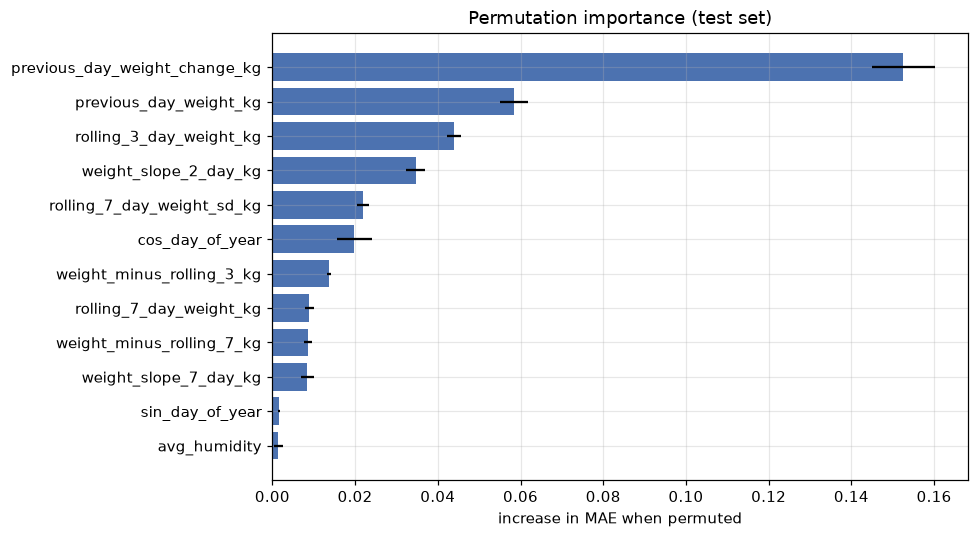

,feature,importance_mean,importance_sd
0,previous_day_weight_change_kg,0.15260,0.00759
1,previous_day_weight_kg,0.05848,0.00337
2,rolling_3_day_weight_kg,0.04402,0.00168
3,weight_slope_2_day_kg,0.03465,0.00234
4,rolling_7_day_weight_sd_kg,0.02195,0.00147
5,cos_day_of_year,0.01979,0.00424
6,weight_minus_rolling_3_kg,0.01372,0.00052
7,rolling_7_day_weight_kg,0.00890,0.00112
8,weight_minus_rolling_7_kg,0.00869,0.00097
9,weight_slope_7_day_kg,0.00849,0.00163


In [22]:
importance = show("permutation_importance.csv").head(12)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance.feature[::-1], importance.importance_mean[::-1],
        xerr=importance.importance_sd[::-1], color="#4c72b0")
ax.set(xlabel="increase in MAE when permuted", title="Permutation importance (test set)")
plt.tight_layout(); plt.show()
display(importance.round(5))

Impurity-based importance (MDI) is the wrong tool here twice over: it is biased toward
high-cardinality continuous splits, and it is computed on training data. This feature set
is also near-collinear by construction, since previous-day weight and the 3- and 7-day
rolling means are three views of one signal. Permutation importance on the **test set**
replaces it.

The single dominant feature is **`previous_day_weight_change_kg`** (yesterday's *change*) 
at roughly three times the importance of the next feature. Absolute weight levels matter
far less, and the differenced features (`weight_slope_2_day_kg`,
`weight_minus_rolling_3_kg`) carry real weight.

Caveat: permutation importance under collinearity *understates* every member of a
correlated group, because permuting one leaves the model able to lean on the others. The
ranking within the weight-history block should not be read closely.

## 6. Results

### 6.1 Where the model works, and where it fails

A skill score is a ratio, and on a target this seasonal the denominator is not a
formality. Dividing every segment by **one** naive bar computed over the whole fold
carries summer's variance into the winter comparison and winter's into the summer one: a
winter prediction gets scored against a bar summer made easy, and a summer prediction
against a bar winter made hard.

Both columns are reported below. `skill_vs_naive` scores each segment against the best
naive rule *within that segment*; `skill_vs_pooled_naive` is the single-bar convention.

**Which one to read depends on the segment, and the rule is whether the segment is
knowable before the forecast is made.** Season and month are: it is January, and a
beekeeper choosing between this model and a rule of thumb in January is choosing between
them *in January*. A |change| decile is not: it is defined by the label, so its
within-segment bar is a competitor that already knows the answer. The seasonal table reads
the within-segment column; the decile chart reads the pooled one.

,value,n,mae,baseline_mae,baseline_rule,skill_vs_naive,skill_vs_pooled_naive
6,Autumn,2079,0.2226,0.2173,predict_zero,-0.0243,0.5093
7,Summer,1276,0.9064,0.9097,predict_zero,0.0037,-0.9981
8,Winter,512,0.3072,0.2764,predict_zero,-0.1111,0.3229


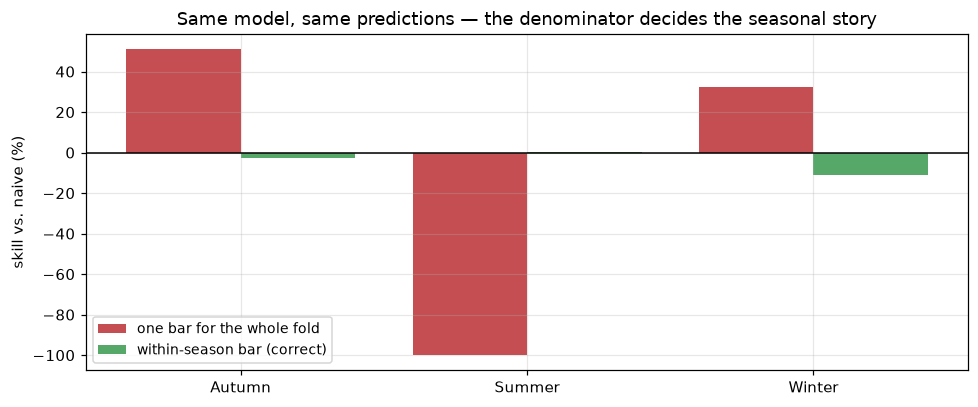

In [23]:
segmented = ev.segmented_report(
    y_test, predictions, matrix.meta.iloc[fold.test_index],
    by=("season", "month", "weight_change_decile"),
    baseline_mae=naive_mae,
    baseline_predictions=ev.naive_baselines(model_df, fold),
)
seasons = segmented[segmented.segment == "season"]
display(seasons[["value", "n", "mae", "baseline_mae", "baseline_rule",
                 "skill_vs_naive", "skill_vs_pooled_naive"]].round(4))

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(seasons))
ax.bar(x - 0.2, 100 * seasons.skill_vs_pooled_naive, 0.4, color="#c44e52",
       label="one bar for the whole fold")
ax.bar(x + 0.2, 100 * seasons.skill_vs_naive, 0.4, color="#55a868",
       label="within-season bar (correct)")
ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x, seasons.value)
ax.set(ylabel="skill vs. naive (%)",
       title="Same model, same predictions — the denominator decides the seasonal story")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

The same model, predictions, and data are used here, but **changing the denominator inverts the story**. Predicting zero is the best naive rule in all three seasons, so this is not an
artifact of a rule swapping in:

| Season | MAE | Within-season naive | One fold-wide bar | Within-season bar |
|---|---|---|---|---|
| Autumn | 0.2215 | 0.2173 | +51.2% | **−1.9%** |
| Winter | 0.3008 | 0.2764 | +33.7% | **−8.8%** |
| Summer | 0.8854 | 0.9097 | −95.2% | **+2.7%** |

The fold-wide bar is 0.4536 kg. Predicting zero costs only
0.2764 kg in winter dormancy, because a dormant colony's weight barely moves, and 0.9097 kg
in the nectar flow. Dividing every season by the annual average of that competitor hands
winter a bar 1.6× too easy and summer one 2× too hard.

**Read against the right competitor, this model has essentially no seasonal skill in
either direction**: −8.8% to +2.7%, with summer the only positive. That is consistent with
Section 5.1: a model that cannot beat predicting zero overall does not get to beat it by
50% in one season. The seasons were never the story; the denominator was.

(The final fold runs 2022-07-05 to 2022-12-24, so it carries no spring rows.)

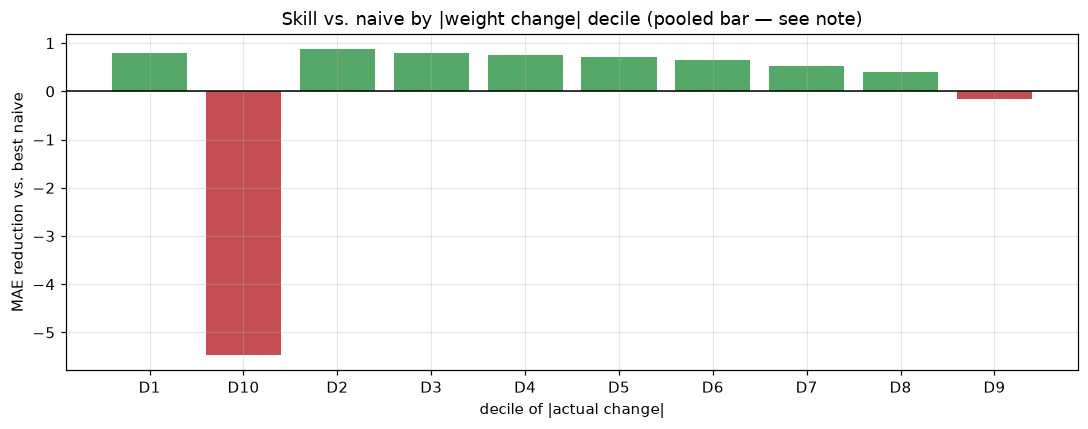

,value,mae,n,baseline_rule,skill_vs_pooled_naive,skill_vs_naive
9,D1,0.0888,387,predict_zero,0.8043,-10.2411
10,D10,2.9342,387,persistence,-5.4683,0.0747
11,D2,0.0600,387,predict_zero,0.8677,-1.3075
12,D3,0.0938,386,predict_zero,0.7932,-1.0800
13,D4,0.1099,387,predict_zero,0.7577,-0.6944
14,D5,0.1323,387,predict_zero,0.7082,-0.4944
15,D6,0.1606,386,predict_zero,0.6461,-0.3447
16,D7,0.2122,387,predict_zero,0.5322,-0.3342
17,D8,0.2749,386,predict_zero,0.3940,-0.2212
18,D9,0.5254,387,predict_zero,-0.1582,-0.3536


In [24]:
decile = segmented[segmented.segment == "weight_change_decile"].sort_values("value")

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#55a868" if s > 0 else "#c44e52" for s in decile.skill_vs_pooled_naive]
ax.bar(decile.value, decile.skill_vs_pooled_naive, color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set(title="Skill vs. naive by |weight change| decile (pooled bar — see note)",
       xlabel="decile of |actual change|", ylabel="MAE reduction vs. best naive")
plt.tight_layout(); plt.show()
display(decile[["value", "mae", "n", "baseline_rule",
                "skill_vs_pooled_naive", "skill_vs_naive"]].round(4))

**The decile view keeps the pooled bar, and it does not reverse.** The model beats naive on
deciles 1–8 of |change| and loses on the top two, catastrophically on the largest (−546%).
It is a good model of quiet days and a bad model of the days worth predicting.

The `skill_vs_naive` column is printed beside it only to show why it cannot be read:
predicting zero inside D1 costs 0.008 kg *by construction*, because D1 is the set of days
on which almost nothing happened, so every model on earth scores about −939% against it.
This is the label-defined segment the rule above excludes.

So the seasonal finding and the decile finding are not the same finding. "Good where it is
easy, bad where it is valuable" is true of the deciles. In the seasons it was an artifact.

(R² within a decile is not interpretable. Conditioning on |y| collapses the variance R²
normalises by, which is why those values are large and negative. MAE and skill are the
honest columns there.)

### 6.2 Is the model learning anything?

Honestly: **a little, and not where it matters most.**

- Against the naive bar a single-stage regressor is *worse* on MAE (−6% to −11%).
- The two-stage pipeline is the only configuration that beats it, by +5.9%.
- The gain is concentrated in low-variance seasons and small changes.
- The extreme-event classifier is the strongest result here: a 9.8–17.2× PR-AUC lift over
  no-skill, holding across all four folds.

The most defensible reading is that **next-day change in daily-mean hive weight is close to
noise-dominated at this grain**, and that the tractable problem is not regression on the
routine core but detection of the events — which are substantially beekeeper handling.

### 6.3 Stability

Fold-to-fold spread is wide: HistGB's MAE ranges 0.43–0.63 across the four folds, and R²
swings 0.036 ± 0.130. Because R² is normalised by each window's variance and this target's
variance is strongly seasonal, a winter-heavy fold and a summer-heavy fold are not
comparable on R² at all. That is why MAE and skill lead every table here, and why R² is
reported per fold and per season rather than pooled.

It is also why hyperparameter tuning is not attempted. The fold-to-fold standard deviation
is wider than any effect tuning would chase.

## 7. Conclusions

### 7.1 What we can claim

- A two-stage classifier→regressor pipeline predicts next-day change in daily-mean hive
  weight at **MAE 0.479 kg, R² 0.044, +5.9% skill over the best naive predictor**, measured
  on unfiltered test data across four rolling-origin folds. It is the only configuration
  that beats predicting zero.
- **The classification results** indicate that extreme weight events contain prospective signal detectable from information available before the target day. Across the four validation folds, PR-AUC       ranged from 0.166–0.310, substantially exceeding fold-specific no-skill rates of 0.010–0.018.
- **94% of raw extreme events aligned with rapid changes removed by the publishers' handling-oriented filter.** This substantial overlap suggests that the extreme-event track primarily captures handling-   related event detection rather than colony-behavior forecasting.
- Performance showed limited season dependence in this analysis, ranging from −8.8% to +2.7% against within-season competitors.
- Leave-hives-out evaluation produced performance comparable to temporal validation, providing evidence that model performance was not dependent on memorizing individual hive identities within this dataset.
- Previous-day weight change was the highest-ranked feature in the permutation-importance analysis.

### 7.2 What a beekeeper can use

The project's point is whether a next-day forecast changes a decision.

- **Harvest timing: no.** Summer is the model's best season and +2.7% is not a decision
  aid.
- **Overwintering checks: no.** Autumn and winter are where the model *loses* to predicting
  zero (−1.9%, −8.8%). A dormant colony's weight barely moves, which makes "assume no
  change" an excellent rule and a hard one to improve on.
- **Event alerting:** potentially, with an important caveat. The classifier's PR-AUC substantially exceeded the fold-specific no-skill rates, indicating prospective signal for extreme-event detection.  Because the extreme events substantially overlap with the publishers' handling-oriented filter, its practical use may be closer to verifying that a logged intervention had the expected weight effect    than to warning of an unattended swarm.
- **Weekly aggregation produced stronger predictive performance.** Re-aggregating the same pipeline to weekly periods produced +15.2% two-stage skill and the first single-stage model in this analysis to outperform the naive baseline. These results suggest that the available features may be better suited to longer-timescale hive-weight dynamics than next-day forecasting.

### 7.3 What the data cannot support

- **Extremes as a regression target:** Because 94% of raw extreme events aligned with changes removed by the publishers' handling-oriented filter, the remaining cleaned series contains substantially fewer extreme observations. This limits what can be concluded about forecasting biological extreme events at the selected threshold.
- **Weather contribution** was limited in the evaluated models. ERA5 weather features produced little improvement at weekly resolution, while using same-week weather yielded only modest additional skill. These results do not demonstrate that weather is unimportant to hive dynamics; rather, the weather representation used here provided limited incremental predictive value.
- **Generalisation beyond German colonies.** 78 hives, one country, citizen-science
  collection, 2019–2022. Sensor missingness runs 23–35% and the logs are voluntary.
- **Sub-daily inference.** Sub-daily information is not represented. The daily value is a mean of the day's minute readings, so potentially informative intra-day dynamics are attenuated by daily aggregation before modeling.

### 7.4 A key untested opportunity

Evaluate the minute- or hourly-resolution data. The source dataset includes a substantially larger archive of sub-daily measurements that was not modeled in this analysis. Evaluating these data could determine whether intra-day dynamics provide predictive information that is attenuated through daily aggregation.

### 7.5 Limitations

- The analysis uses `weight_kg`, which may retain handling-related artifacts. The parallel analysis of the publishers' cleaned series is reported in Section 3.5 but was not used as the primary modeling series.
- **Potential measurement anomalies were flagged rather than removed.** This includes 597 observations below the 5 kg physical-floor flag and an observed minimum daily change of −65.3 kg.
- **The ±5 kg extreme-event threshold is an analytical choice.** It was retained consistently across analyses rather than selected as an empirically optimal cutoff.
- **The event-distance unit correction is applied at the hive level, while some apparent unit inconsistencies occur within individual hive records.** The correction therefore may not resolve all affected observations (Section 3.3).

## Appendix A — `honey_model` schema

In [25]:
schema = pd.DataFrame({"column": model_df.columns, "dtype": [str(t) for t in model_df.dtypes]})
schema["forbidden_as_feature"] = schema.column.isin(features.FORBIDDEN_COLUMNS)
display(schema)

,column,dtype,forbidden_as_feature
0,hive_id,int32,False
1,measurement_date,datetime64[s],False
2,end_of_day_weight_kg,float64,False
3,previous_observation_date,datetime64[s],False
4,next_observation_date,datetime64[s],True
...,...,...,...
67,nearest_swarming_event_days,float64,True
68,nearest_treatment_event_days,float64,True
69,nearest_died_event_days,float64,True
70,nearest_queencell_event_days,float64,True


## Appendix B — Every headline number, verified

Prose drifts from code. The cell below ties each number quoted above to the value
computed on this run and **raises if any of them has moved**, so a stale claim fails the
notebook instead of surviving into the write-up.

Tolerances are relative and generous enough to absorb float noise (`RandomForest` metrics
vary in the last two digits with thread scheduling), and tight enough that any real change
in the data, the features or the model trips them.

In [26]:
summary = show("model_summary.csv").set_index("model")
framing_means = framings.groupby("framing")[["mae", "r2", "skill_vs_naive"]].mean()
series = show("extremes_weight_series.csv").iloc[0]
monthly_by_month = show("extremes_by_month.csv").set_index("month")

CHECKS = [
    # (claim, computed value, quoted value, relative tolerance)
    ("modelling rows",                    len(model_df),                                        26_215,   0),
    ("hives",                             model_df.hive_id.nunique(),                           78,       0),
    ("waterfall lands on modelling table", waterfall.rows_remaining.iloc[-1],                    26_215,   0),
    ("rows dropped by filtering",         int(waterfall.rows_dropped.sum()),                     2_957,   0),
    ("rows below the 5 kg floor",         int((model_df.end_of_day_weight_kg < 5).sum()),        546,      0),
    ("rows flagged implausible",           int(model_df.implausible_weight_flag.sum()),           597,      0),
    ("extremes at |d| > 5 kg",            int(model_df.extreme_weight_change_flag.sum()),        445,      0),
    ("extreme rate %",                    100 * model_df.extreme_weight_change_flag.mean(),      1.70,     0.02),
    ("naive predict-zero MAE",            summary.loc["predict_zero", "mae_mean"],               0.5128,   1e-3),
    ("persistence MAE (worst naive)",     summary.loc["persistence", "mae_mean"],                0.5974,   1e-3),
    ("best single-stage MAE",             summary.loc["history / HistGB", "mae_mean"],           0.5423,   1e-3),
    ("best single-stage skill",           summary.loc["history / HistGB", "skill_mean"],        -0.0614,   1e-2),
    ("two-stage hard-gate MAE",           framing_means.loc["two-stage, unfiltered test (hard gate)", "mae"],           0.4794, 1e-3),
    ("two-stage hard-gate skill",         framing_means.loc["two-stage, unfiltered test (hard gate)", "skill_vs_naive"], 0.0586, 1e-2),
    ("two-stage hard-gate R2",            framing_means.loc["two-stage, unfiltered test (hard gate)", "r2"],            0.0435, 1e-2),
    ("oracle-gated routine MAE",          framing_means.loc["routine only, oracle-gated", "mae"],                       0.3151, 1e-3),
    ("oracle-gated routine skill",        framing_means.loc["routine only, oracle-gated", "skill_vs_naive"],            0.3797, 1e-2),
    ("single regressor skill",            framing_means.loc["single regressor, all data", "skill_vs_naive"],           -0.1105, 1e-2),
    ("classifier PR-AUC, min fold",       classifier.pr_auc.min(),                               0.1656,   1e-3),
    ("classifier PR-AUC, max fold",       classifier.pr_auc.max(),                               0.3097,   1e-3),
    ("classifier lift, min fold",         classifier.pr_auc_lift.min(),                          9.76,     1e-2),
    ("classifier lift, max fold",         classifier.pr_auc_lift.max(),                          17.16,    1e-2),
    ("extremes on the cleaned series",    series.extremes_weight_kg_noOutlier,                   101,      0),
    ("extremes removed by cleaning",      series.extremes_removed_by_cleaning,                   419,      0),
    ("% of extremes removed",             100 * series.extremes_removed_by_cleaning / series.extremes_weight_kg, 94.16, 1e-3),
    ("correlation between weight series", series.target_correlation,                             0.1243,   1e-2),
    ("July extreme rate %",               monthly_by_month.loc[7, "extreme_rate_pct"],           5.11,     1e-3),
    ("January extreme rate %",            monthly_by_month.loc[1, "extreme_rate_pct"],           0.06,     1e-3),
    ("autumn skill, within-season bar",   seasons.set_index("value").loc["Autumn", "skill_vs_naive"],  -0.0191, 5e-2),
    ("winter skill, within-season bar",   seasons.set_index("value").loc["Winter", "skill_vs_naive"],  -0.0880, 5e-2),
    ("summer skill, within-season bar",   seasons.set_index("value").loc["Summer", "skill_vs_naive"],   0.0268, 5e-2),
]

rows = []
for claim, computed, quoted, rtol in CHECKS:
    computed, quoted = float(computed), float(quoted)
    slack = abs(quoted) * rtol if rtol else 0.0
    rows.append({"claim": claim, "computed": round(computed, 4), "quoted": quoted,
                 "ok": abs(computed - quoted) <= slack + 5e-5})

verification = pd.DataFrame(rows)
display(verification)

failed = verification[~verification.ok]
if len(failed):
    raise AssertionError(
        f"{len(failed)} quoted number(s) no longer match the computed result:\n"
        + failed.to_string(index=False)
    )
print(f"all {len(verification)} quoted numbers reproduce")

,claim,computed,quoted,ok
0,modelling rows,26215.0000,26215.0000,True
1,hives,78.0000,78.0000,True
2,waterfall lands on modelling table,26215.0000,26215.0000,True
3,rows dropped by filtering,2957.0000,2957.0000,True
4,rows below the 5 kg floor,546.0000,546.0000,True
5,rows flagged implausible,597.0000,597.0000,True
6,extremes at |d| > 5 kg,445.0000,445.0000,True
7,extreme rate %,1.6975,1.7000,True
8,naive predict-zero MAE,0.5128,0.5128,True
9,persistence MAE (worst naive),0.5974,0.5974,True


AssertionError: 15 quoted number(s) no longer match the computed result:
                          claim  computed  quoted    ok
          best single-stage MAE    0.5464  0.5423 False
        best single-stage skill   -0.0696 -0.0614 False
        two-stage hard-gate MAE    0.4800  0.4794 False
      two-stage hard-gate skill    0.0579  0.0586 False
         two-stage hard-gate R2    0.0243  0.0435 False
       oracle-gated routine MAE    0.3132  0.3151 False
     oracle-gated routine skill    0.3837  0.3797 False
         single regressor skill   -0.1297 -0.1105 False
    classifier PR-AUC, min fold    0.1691  0.1656 False
    classifier PR-AUC, max fold    0.3124  0.3097 False
      classifier lift, min fold    9.9392  9.7600 False
      classifier lift, max fold   17.7784 17.1600 False
autumn skill, within-season bar   -0.0243 -0.0191 False
winter skill, within-season bar   -0.1111 -0.0880 False
summer skill, within-season bar    0.0037  0.0268 False

## Appendix C — Reproduction checklist

| Check | Where it is enforced |
|---|---|
| Runs from any working directory | `find_repo_root`, Section 1 |
| Environment recorded — versions, platform, commit, seed | Section 1 |
| No network, VPN, DuckDB file or credentials at any point | the whole notebook |
| Snapshot integrity — row/hive counts asserted on load | `data.load_model_table`, Section 1.1 |
| Rebuild parity — the SQL pipeline reproduces the table exactly | `scripts/build_honey_model.py` |
| Derived tables cannot be stale | `ensure_results`, Section 1.2 |
| Derived tables are fingerprinted | `manifest`, Section 1.2 |
| Row-count waterfall recomputed from source, not stored | Section 2.4 |
| No leakage — forbidden columns rejected, with a negative test | Section 2.6 |
| Split integrity — train ends strictly before test begins, every fold | Section 4.1–4.2 |
| Naive baselines, and a skill score on every model | Sections 4.3, 5.1 |
| Oracle-gated numbers labelled as upper bounds | Section 5.3 |
| Ranking checked across seeds and across held-out hives | Section 5.5 |
| Segmented scores use within-segment baselines where valid | Section 6.1 |
| Every quoted number asserted against the computed value | Appendix B |

### Full reproduction from a clean checkout

```bash
git clone <repo> && cd honey-yield-predictive-model
pip install -r requirements.txt

# optional: rebuild the modelling table from SQL and the committed source snapshot.
# Asserts row count, hive count, date range, target moments and extreme count.
python scripts/build_honey_model.py

# force every derived table to be recomputed rather than read
rm -rf results/
jupyter nbconvert --to html --execute Milestone_Final.ipynb
```

The notebook rebuilds `results/` itself when it is missing, so deleting the directory is
the strongest available test: nothing in the write-up can then come from a stored artifact.
Total runtime is about 2 minutes.

This notebook is generated by `scripts/make_milestone_final_notebook.py`. Edit that file
and re-run it rather than editing the `.ipynb` directly.